In [95]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module ="openpyxl")

In [96]:
file_path = r"C:\Users\rajeshkumar.t\Desktop\ML\tranctions.csv"
df= pd.read_csv(file_path, low_memory =False)
print(df.columns)

Index(['transaction_yr', 'transaction_mth', 'transaction_wk', 'transaction_dt',
       'transaction_status', 'transaction_source', 'live_response_code',
       'payment_instrument', 'bank_code', 'hyp_flag', 'asp_flag',
       'merchant_id', 'merchant_status', 'marketplace_id', 'pg_id',
       'flipkart_emi_flag', 'marketplace_context', 'is_shopsy_order',
       'emi_flag', 'adonc_flag', 'count_of_tx', 'acct_cnt', 'tot_amt',
       'tot_eff_amt_paymnt'],
      dtype='object')


In [97]:
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
df = df[df['transaction_dt'] !="transaction_dt"]

In [98]:
df_ts = df.groupby('transaction_dt')['count_of_tx'].sum().reset_index()

In [99]:
print(ts_df.head(5))

  transaction_dt  count_of_tx
0     2025-12-01      8759739
1     2025-12-02      9056756
2     2025-12-03      8893863
3     2025-12-04     10000780
4     2025-12-05     10232701


In [100]:
df_ts['transaction_dt'] = pd.to_datetime(df_ts['transaction_dt'])
df_ts = df_ts.set_index('transaction_dt')
df_ts = df_ts.iloc[:-2]
df_ts = df_ts.asfreq('D').fillna(0)
df_ts['count_of_tx_scaled'] = df_ts['count_of_tx']/1000

In [101]:
model = SARIMAX(df_ts['count_of_tx_scaled'],
                order = (1,1,1),
                seasonal_order= (1,1,1,7),
                enforce_stationarity =False,
                enforce_invertibility = False)

In [102]:
print("Training SARIMA Model")
results = model.fit()

Training SARIMA Model


In [103]:
forecast_object = results.get_forecast(steps=30)
forecast_values = forecast_object.predicted_mean
conf_int = forecast_object.conf_int()

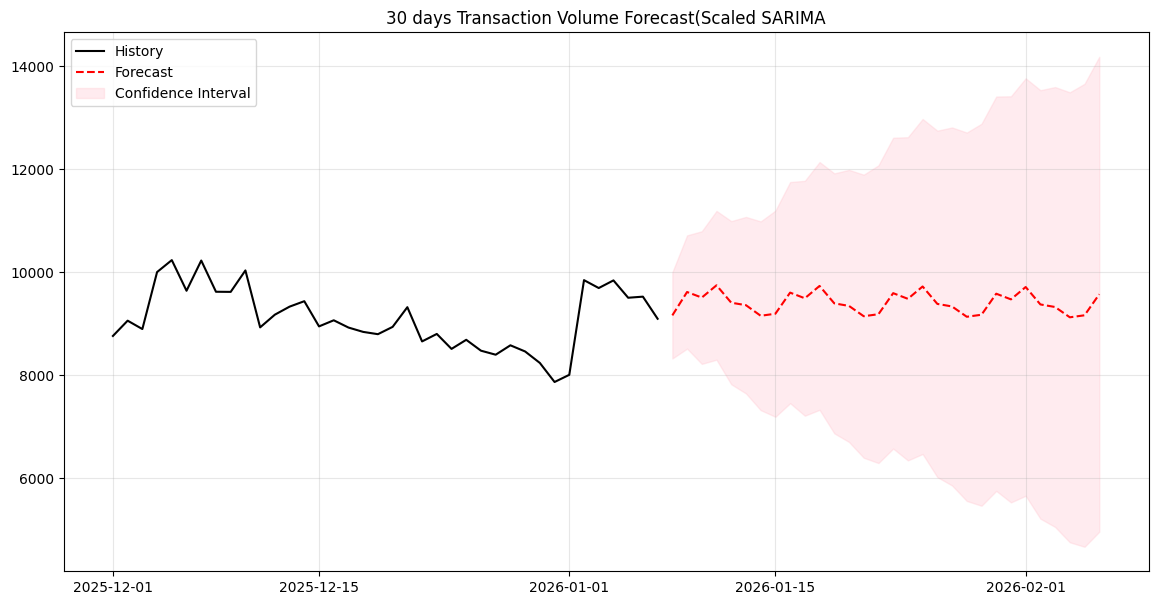

In [104]:
plt.figure(figsize=(14,7))
plt.plot(df_ts.index[-60:], df_ts['count_of_tx_scaled'][-60:], label ='History', color ='black')
plt.plot(forecast_values.index, forecast_values, label='Forecast', color='red', linestyle='--')
plt.fill_between(forecast_values.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='pink',alpha=0.3,label = 'Confidence Interval')
plt.title('30 days Transaction Volume Forecast(Scaled SARIMA')
plt.legend()
plt.grid(True, alpha=0.3)


plt.show()